In [3]:
using Oceananigans, CairoMakie

In [4]:
grid = RectilinearGrid(size = (128, 128),
                       x = (0, 2π),
                       y = (0, 2π),
                       topology = (Periodic, Periodic, Flat))

model = NonhydrostaticModel(grid; advection=WENO())

ϵ(x, y) = 2rand() - 1
set!(model, u=ϵ, v=ϵ)

simulation = Simulation(model; Δt=0.01, stop_iteration=100)
run!(simulation)

[ Info: Initializing simulation...
[ Info:     ... simulation initialization complete (270.873 ms)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (2.602 seconds).
[ Info: Simulation is stopping after running for 6.176 seconds.
[ Info: Model iteration 100 equals or exceeds stop iteration 100.


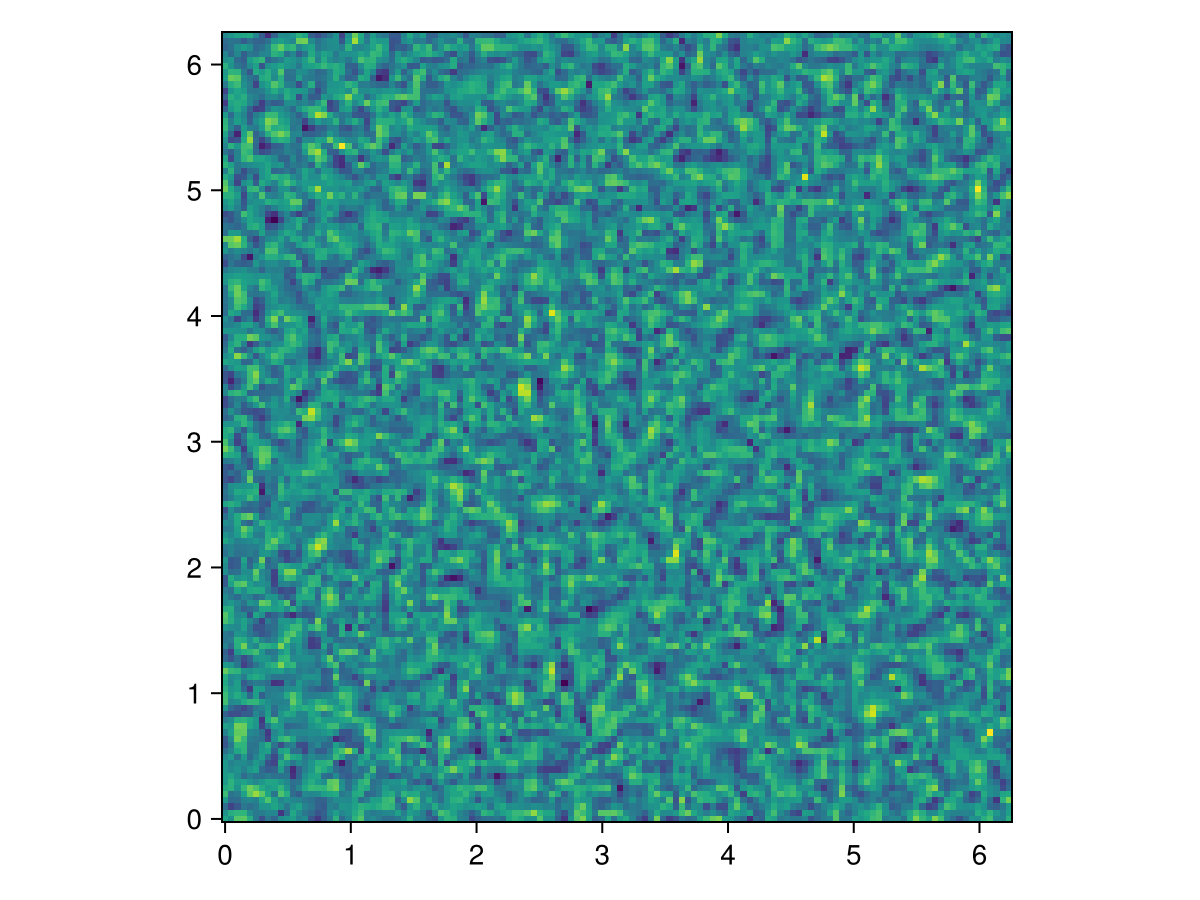

In [5]:
u, v, w = model.velocities
ζ = Field(∂x(v) - ∂y(u))

heatmap(ζ, axis=(; aspect=1))

[ Info: Initializing simulation...
[ Info:     ... simulation initialization complete (6.246 ms)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (18.831 ms).
[ Info: Simulation is stopping after running for 6.807 seconds.
[ Info: Model iteration 500 equals or exceeds stop iteration 500.


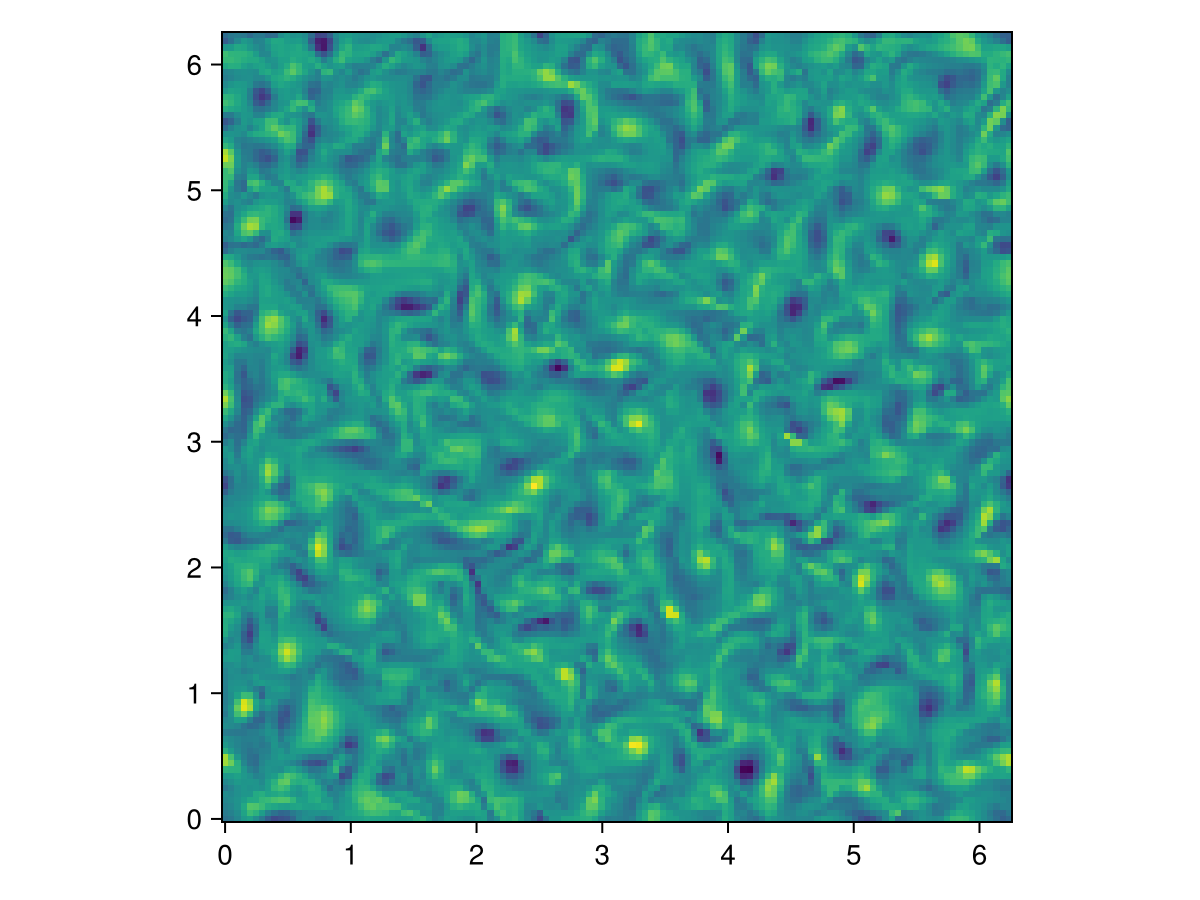

In [6]:
simulation.stop_iteration += 400
run!(simulation)

heatmap(ζ, axis=(; aspect=1))